In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf # k线图
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

### 创建你的第一个量化策略
1. 参数设置：ticker 数据获取与标准化
2. 参数设置：captical, commission, benchmark
3. 策略与运行：indicators, signals
4. 策略与运行：cross-order, limit, pos, 涨跌停
5. 统计与验证：daily profit and loss, position value, total value, 日盈亏数据逐笔核对
6. 统计与验证：strategy statistics, 生成策略报告
7. 结果可视化：持仓收益、最大回撤、日盈亏
8. 结果可视化：市场基准（beta）对比

In [2]:
# 全局参数设置（或数据模块）：工商银行为例
ticker = "601398.SS"
benchmark_ticker = "000001.SS"
start_date = "2020-10-20"
end_date = "2025-10-20"

# 策略模块：全局参数
boll_period = 5
boll_k = 1.5

#### 参数设置：ticker 数据获取与标准化
- 数据获取：yf.download(), 定义参数（股票代码、开始日期、结束日期、复权方式）
- 数据清洗：nan值 -> dropna
- 数据预览：整体看下数据

In [3]:
# 函数1：数据获取
def fetcher_data(ticker:str,start_date:str,end_date:str,auto_clean=True) -> pd.DataFrame:
    """ 获取数据 """
    try:
        print("正在获取历史数据：",ticker, start_date, end_date)
        data = yf.download(tickers=ticker,start=start_date,end=end_date,progress=False)
        # yfinance 个性化处理：去除第二行的列名，即ticker值
        data = data.droplevel(level=1,axis=1)
        print("完成数据获取，共有记录（条数）：", len(data))

        if auto_clean:
            clean_data(data)
    
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return pd.DataFrame

# 函数2：数据清洗
def clean_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 清洗数据：缺失值 """
    try:
        count_nan = data.isnull().sum().sum()
        print("当前data共有缺失值（个数）：",count_nan)
        data = data.dropna()
        count_nan = data.isnull().sum().sum()
        print("缺失值处理完毕，当前缺失值（个数）：",count_nan)
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return data

# 函数3：数据预览
def preview_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 按需要的格式预览数据 """
    print("数据预览：",data)

In [4]:
data = fetcher_data(ticker,start_date,end_date)
preview_data(data)

正在获取历史数据： 601398.SS 2020-10-20 2025-10-20
完成数据获取，共有记录（条数）： 1212
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price          Close      High       Low      Open     Volume
Date                                                         
2020-10-20  3.790389  3.813223  3.767555  3.813223  240689629
2020-10-21  3.843668  3.858890  3.767555  3.790389  325876182
2020-10-22  3.851279  3.858891  3.820834  3.843668  191063454
2020-10-23  3.851279  3.866502  3.828446  3.843668  235615563
2020-10-26  3.820835  3.858891  3.813224  3.851280  179783563
...              ...       ...       ...       ...        ...
2025-10-13  7.270000  7.360000  7.230000  7.320000  395738605
2025-10-14  7.500000  7.500000  7.220000  7.260000  693878140
2025-10-15  7.460000  7.540000  7.420000  7.470000  407599319
2025-10-16  7.630000  7.650000  7.430000  7.430000  495623345
2025-10-17  7.620000  7.720000  7.570000  7.630000  408700246

[1212 rows x 5 columns]


#### 参数设置：capital, commission, slippage, benchmark
- initial_capital：初始资金，决定能买多少股票，是收益率、仓位计算的基准，回测设置为尽可能大的整数（如100万）
- commission: 交易手续费（佣金 + 税费），总共约为千1，即0.1% -> 0.001
- slippage: 滑点（成交价偏差），实际成交价与理论信号价的偏差，反应市场流动性和成交延迟，回测过程中设置为万5，即0.05% -> 0.0005
- benchmark: 市场基准（beta），使用上证指数 000001.SS

In [5]:
# 全局交易参数设置
trading_config = {
    "initial_capital":1000000,
    "commission":0.001, # a股买入的话是在0.0003，卖出的话 0.0007，通用使用0.001
    "slippage":0.0005
}

In [6]:
benchmark_data = fetcher_data(benchmark_ticker,start_date,end_date)
preview_data(benchmark_data)

正在获取历史数据： 000001.SS 2020-10-20 2025-10-20
完成数据获取，共有记录（条数）： 1212
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price             Close         High          Low         Open  Volume
Date                                                                  
2020-10-20  3328.100098  3328.100098  3293.770020  3307.149902  165100
2020-10-21  3325.020020  3332.149902  3304.169922  3332.149902  177600
2020-10-22  3312.500000  3320.879883  3281.370117  3315.820068  165900
2020-10-23  3277.997070  3326.049072  3276.620117  3308.157959  174200
2020-10-26  3251.118896  3264.446045  3226.602051  3258.702881  167700
...                 ...          ...          ...          ...     ...
2025-10-13  3889.501953  3895.830078  3800.104980  3800.104980  709500
2025-10-14  3865.229004  3918.436035  3851.121094  3910.781982  800800
2025-10-15  3912.208984  3912.291016  3857.666992  3867.535889  645000
2025-10-16  3916.228027  3931.050049  3899.166992  3900.683105  595500
2025-10-17  3839.754883  3921.064941  

In [7]:
# 函数4：对比投资标的与市场基准的价格曲线
def plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data,auto_normalize=True):
    combined_data = pd.DataFrame({
        ticker: data['Close'],
        benchmark_ticker: benchmark_data['Close']
    })

    # 数据标准化（0~1）：解决价格差异太大导致无法直观对比的问题
    if auto_normalize:
        combined_data = combined_data / combined_data.iloc[0] * 100
        ylable = "相对涨幅（%）"
    else:
        ylable = "收盘价"

    combined_data.plot(figsize=(12,5), linewidth=2)
    plt.title(f"{ticker} vs {benchmark_ticker} 收盘价对比")
    plt.xlabel("日期")
    plt.ylabel(ylable)
    plt.grid(alpha=0.3)

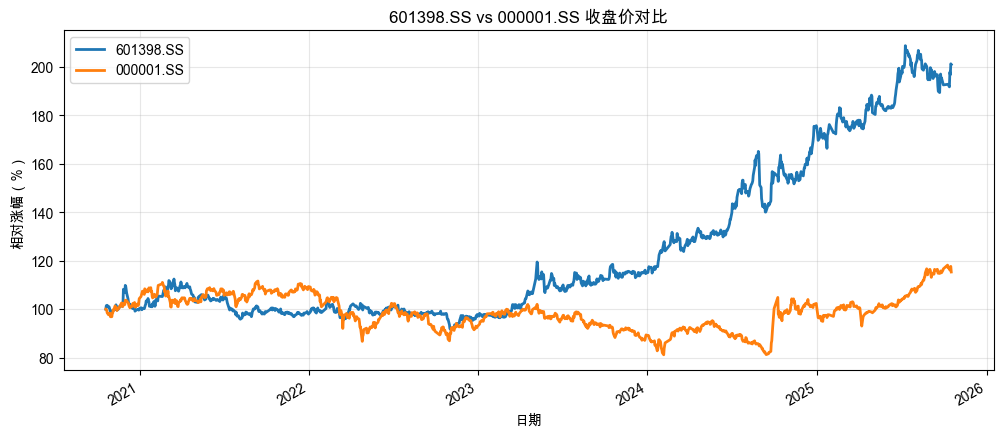

In [8]:
plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data)

#### 策略与运行：indicators, signals
- 核心作用: 找到特征/因子 => 建立特征模型（单个因子/多个因子/权重配置）=> 创建策略规则 => 生成交易信号（涉及配对交易的问题）=> 进行后续回测
- 因子概念: 基于此进行量化策略的规则编写，比如：技术指标（KDJ-动量因子、MA-趋势因子）、基本面指标（PE-价值因子）
- 代码实现: 单因子（BOLL）=> 价格上穿下轨：买入/做多，价格下穿上轨：卖出/平仓/做空
- 函数创建: def calculate_boll（因子指标模块）、def generate_signals（因子指标/策略模块）、def plot_signals（可视化信号-验证计算）

In [9]:
# 函数4：def calculate_boll（因子指标模块）
def calculate_boll(data:pd.DataFrame,period:int,std_k:int) -> pd.DataFrame:
    """ 计算Boll布林带指标
        - 中轨：n日移动均线
        - 上轨：n日移动均线 + k * n日收盘价std
        - 下轨：n日移动均线 - k * n日收盘价std
    """
    try:
        data['BOLL_MA'] = data['Close'].rolling(window=period).mean()
        data['BOLL_STD'] = data['Close'].rolling(window=period).std()
        data['BOLL_UP'] = data['BOLL_MA'] + std_k * data['BOLL_STD']
        data['BOLL_DN'] = data['BOLL_MA'] - std_k * data['BOLL_STD']
        print(f"已完成指标计算：BOLL, 周期-{period}, 标准差倍数-{std_k}")
        return data
    except Exception as e:
        print("BOLL计算异常：",e)
        return pd.DataFrame

# 函数5：def generate_signals（因子指标/策略模块）
def generate_signals(data:pd.DataFrame) -> pd.DataFrame:
    """ 通用模块：参数化设置实现多因子信号的生成，也是核心需要修改的策略规则逻辑 """
    try:
        data['Signal'] = 0
        
        # 以下内容为信号生成逻辑，可以自定义，核心是获取 Signal 列的值（1买入 -1卖出）
        
        # 单因子（BOLL）=> 价格上穿下轨：买入/做多，价格下穿上轨：卖出/平仓/做空
        prev_price = data['Close'].shift(1)
        buy_condition = (prev_price<=data['BOLL_DN']) & (data['Close']>=data['BOLL_DN'])
        sell_condition = (prev_price>=data['BOLL_UP']) & (data['Close']<=data['BOLL_UP'])

        data.loc[buy_condition,'Signal'] = 1
        data.loc[sell_condition,'Signal'] = -1
        print(f"已完成信号生成：BOLL，买入信号次数：{buy_condition.sum()}，卖出信号次数：{sell_condition.sum()}")
        return data
    except Exception as e:
        print("信号生成异常：",e)
        return pd.DataFrame
        

# 函数6：def plot_signals（可视化信号-验证计算）
def plot_signals(data:pd.DataFrame,title:str):
    """ 绘制指标与信号 """

    # 定义子图：布林带上中下轨、买入卖出信号
    buy_signal = np.where(data['Signal']==1,data['Close'],np.nan)
    sell_signal = np.where(data['Signal']==-1,data['Close'],np.nan)
    
    subplots = [
        mpf.make_addplot(data['BOLL_MA'],color='blue',linestyle='--',label='Middle'),
        mpf.make_addplot(data['BOLL_UP'],color='red',linestyle='--',label='Upper'),
        mpf.make_addplot(data['BOLL_DN'],color='green',linestyle='--',label='Lower'),
        mpf.make_addplot(buy_signal, type='scatter', marker='^', markersize=100, color='red',label='Buy'),
        mpf.make_addplot(sell_signal, type='scatter', marker='v', markersize=100, color='green',label='Sell')
    ]

    # 绘制
    mpf.plot(
        data,
        type='candle',
        style='yahoo',
        title=title,
        addplot=subplots,
        volume=False,
        figsize=(12,6),
        tight_layout=True,
        xrotation=15,
    )

已完成指标计算：BOLL, 周期-5, 标准差倍数-1.5
已完成信号生成：BOLL，买入信号次数：21，卖出信号次数：23


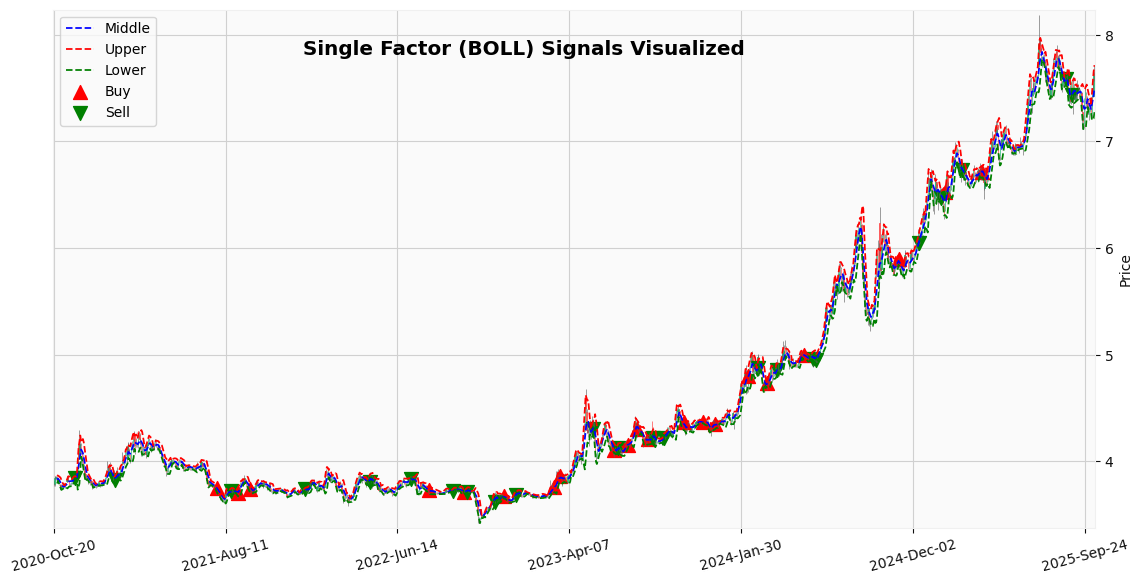

In [10]:
indicators = calculate_boll(data,boll_period,boll_k)
signals = generate_signals(indicators)
plot_signals(signals,"Single Factor (BOLL) Signals Visualized")

#### 策略与运行：cross-order, limit, pos, 涨跌停
- 核心功能：执行买卖交易、存储交易记录、每笔交易（卖出）的盈亏分析（净利润，收益率）
- cross-order 撮合订单：买入价格 >= 卖出价格（卖盘）就会自动撮合，否则就会挂单表示委托状态中
- 委托单类型：market 市价单 => 滑点、limit 限价单 => 无法交易 => limit price ± 0.001%
- 处理涨跌停：前收盘价 > ± 10% 则无法成交
- 函数：def execute_trade => 下订单+存交易记录

In [11]:
# 设置交易信息初始值（全局） => 思考个人账户页面的汇总数据有哪些
trading_state = {
    'cash': trading_config['initial_capital'], # 账户可用资金
    'positions': {}, # 存储投资标的持仓，如：{"000001.SS":10000, "601398.SS":2000}
    'trades': [], # 存放交易记录：price,quantity,date,cost,net_revenue,profit_rate
    'values': [] # 存放每日盈亏数据：position * price -> pos value (+cash)-> total value->今明总值比较->日盈亏
}

In [12]:
# 函数7：def execute_trade => 下订单+存交易记录
def execute_trade(symbol:str, quantity: int, price: float, date: pd.Timestamp, commission: float = trading_config['commission']):
    """
    执行交易：买入、卖出、交易记录；实际的交易接口交互的过程中，交易信息是直接发给券商API => 进行订单委托、更新账户信息 => 得到状态码
    """
    try:
        # 买入
        if quantity > 0:
            # 买入：执行交易 => 是否满足可交易条件：可用资金足够 => 更新持仓信息
            cost = quantity * price * (1+commission)
            if cost <= trading_state['cash']:
                trading_state['cash'] -= cost # 资金流出
                trading_state['positions'][symbol] = trading_state['positions'].get(symbol,0) + quantity # 流入
                # 买入：记录交易 => 汇总信息并添加至 trading_state['trades'] => cost 总成本
                trade_record = {
                    'symbol':symbol,
                    'quantity':quantity,
                    'price':price,
                    'type':'buy',
                    'timestamp':date,
                    'cost':cost,
                    'commission':cost - (quantity * price)
                }
                trading_state['trades'].append(trade_record)

                print(f"➕买入成功！{symbol} +{quantity}股 @{price} 总成本 {cost} 可用资金 {trading_state['cash']}")
            else:
                print(f"❌可用资金不足！总成本 {cost} 可用资金 {trading_state['cash']}")
                
        # 卖出
        else:
            quantity = abs(quantity)
            # 卖出：执行交易 => 是否满足可交易条件：仓位pos足够 => 计算收益 => 更新持仓信息
            if trading_state['positions'].get(symbol,0) >= quantity:
                # 计算净收益
                gross_revenue = quantity * price # 按当前价格和仓位卖出的市值
                commission_cost = gross_revenue * commission # 计算佣金
                net_revenue = gross_revenue - commission_cost # 纯收益

                # 找到买入成本
                buy_cost = get_latest_buy_cost(symbol)
                
                # 计算盈亏 profit and loss 盈亏
                profit_loss = net_revenue - buy_cost # 当前卖出和此前买入的收益/亏损值（差值）
                profit_rate = profit_loss / buy_cost # >0 正收益 <0 负收益
                profit_rate_pct = f"{profit_rate:.2%}"

                # 更新持仓和可用资金
                trading_state['positions'][symbol] -= quantity # 减持，资金流出
                trading_state['cash'] += net_revenue
                
                # 卖出：记录交易 => 汇总信息并添加至 trading_state['trades'] => 净收益 net_revenue, 收益比
                trade_record = {
                    'symbol':symbol,
                    'quantity':quantity,
                    'price':price,
                    'type':'sell',
                    'timestamp':date,
                    'gross_revenue':gross_revenue,
                    'commission':commission_cost,
                    'net_revenue':net_revenue,
                    'buy_cost':buy_cost,
                    'profit_loss':profit_loss,
                    'profit_rate':profit_rate,
                    'profit_rate_pct':profit_rate_pct
                }
                trading_state['trades'].append(trade_record)

                print(f"➖卖出成功！{symbol} -{quantity}股 @{price} 净收益 {net_revenue} 盈亏 {profit_loss} 盈亏比 {profit_rate_pct} 可用资金 {trading_state['cash']}")
            else:
                print(f"❌可用仓位不足！总仓位 {trading_state['positions'].get(symbol,0)}")
                
    except Exception as e:
        print(f"交易异常：{e}")

# 函数8：辅助计算函数，找到最近买入记录对应的总成本
def get_latest_buy_cost(symbol:str) -> float:
    """
    获取指定投资标的的最新买入成本（全进全出策略，即：无加减仓逻辑）
    """
    for trade in reversed(trading_state['trades']):
        if trade['symbol'] == symbol and trade['type'] == 'buy':
            return trade['cost'] 
    print(f"⚠️警告：未找到 {symbol} 的买入记录")
    return 0.0

In [13]:
# execute_trade(ticker, 100000, 6.78, "2025-10-31")
# execute_trade(ticker, -100000, 6.78, "2025-10-31")

# execute_trade(benchmark_ticker, 80000, 4.28, "2025-10-31")
# execute_trade(benchmark_ticker, -80000, 5.76, "2025-10-31")

# trading_state
pd.DataFrame(trading_state['trades'])

""


#### 统计与验证：daily profit and loss, position value, total value, 日盈亏数据逐笔核对
- 每日盈亏：当日的总市值 - 昨日的总市值 => 反应你持仓标的的整体涨跌幅情况
- 账户总市值：总市值 = 持仓市值（获取当前投资标的的股数/份额） + 账户可用资金
- 核心功能和函数：根据交易信号执行交易（进行回测+执行策略）=> def run_strategy 

In [14]:
# 函数9：def run_strategy
def run_strategy(signals:pd.DataFrame, symbol:str):
    """
    根据交易信号执行交易，并将计算的市值和盈亏数据进行存储
    """
    # 验证是否有 signal 列
    if 'Signal' not in signals.columns:
        raise ValueError("Data中必须包含 Signal 列")

    # 按行遍历数据 => 获取 date, price, signal => 并后续计算quantity
    for i, (date,row) in enumerate(signals.iterrows()):
        signal = row['Signal']
        price = row['Close']
        
        # 买入 - 计算按可用资金最多可以买入的股数（全仓进出 + 佣金），如果非全仓 - 可用资金的10%
        if signal == 1:
            max_quantity = int(trading_state['cash'] / ( price * (1 + trading_config['commission'])))
            if max_quantity > 0:
                execute_trade(symbol, max_quantity, price, date)
        # 卖出
        elif signal == -1:
            current_quantity = trading_state['positions'].get(symbol,0)
            if current_quantity > 0:
                execute_trade(symbol, -current_quantity, price, date)

        # 计算市值：持仓、账户总值
        position_value = trading_state['positions'].get(symbol,0) * price
        total_value = position_value + trading_state['cash']

        # 计算盈亏：当日 - 昨日总值
        if i == 0:
            daily_pnl = 0
        else:
            previous_value = trading_state['values'][-1]['total_value']
            daily_pnl = total_value - previous_value # 昨日市值

        # 存储数据
        daily_record = {
            'date':date,
            'signal':signal,
            'price':price,
            'cash':trading_state['cash'],
            'position':trading_state['positions'].get(symbol,0),
            'position_value':position_value,
            'total_value':total_value,
            'daily_pnl':daily_pnl
        }

        trading_state['values'].append(daily_record)

        # 打印数据
        print(f"📅{date.strftime('%Y-%m-%d')} 信号{signal} 价格{price:.2f} 仓位{trading_state['positions'].get(symbol,0)} 仓位市值{position_value:.2f} 可用资金{trading_state['cash']:.2f} 总市值{total_value:.2f} 日盈亏{daily_pnl:.2f}")

        # 存储csv -> 函数外实现，便于核对数据

In [15]:
run_strategy(signals,ticker)

📅2020-10-20 信号0.0 价格3.79 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-21 信号0.0 价格3.84 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-22 信号0.0 价格3.85 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-23 信号0.0 价格3.85 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-26 信号0.0 价格3.82 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-27 信号0.0 价格3.83 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-28 信号0.0 价格3.81 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-29 信号0.0 价格3.78 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-10-30 信号0.0 价格3.74 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-11-02 信号0.0 价格3.76 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-11-03 信号0.0 价格3.77 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-11-04 信号0.0 价格3.77 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-11-05 信号0.0 价格3.77 仓位0 仓位市值0.00 可用资金1000000.00 总市值1000000.00 日盈亏0.00
📅2020-11-06 信号0.0 价格3.78 

In [16]:
pd.DataFrame(trading_state['values']).to_csv('daily_pnl_records.csv',index=False)
pd.DataFrame(trading_state['trades']).to_csv('trade_records.csv',index=False)

#### 统计与验证：strategy statistics, 生成策略报告
- 计算策略评估指标：收益、风险、绩效类的；期初/期末的日期、资金；交易统计（trades)；日均统计数据；
- 核心功能和函数：def run_backtest_metrics(values,trades) => 计算指标，并进行格式化输出

In [17]:
# 函数10：def run_backtest_metrics
def run_backtest_metrics(values_data:pd.DataFrame,trades_data:pd.DataFrame):
    """
    根据每日盈亏、市值、交易记录，计算策略评估指标及重要信息数据
    """

    # 准备数据：将values的index设置为date，并确保日期数据的格式正确
    values_data['date'] = pd.to_datetime(values_data['date'])
    values_data.set_index('date',inplace=True)
    trades_data['timestamp'] = pd.to_datetime(trades_data['timestamp'])

    # 进入计算的部分

    # 1.日期信息
    first_trade_date = values_data.index[0]
    last_trade_date = values_data.index[-1]
    total_trading_days = len(values_data)
    trading_years = total_trading_days / 252
    
    profitable_days = (values_data['daily_pnl'] > 0).sum() # 赚钱的交易日总天数
    losing_days = (values_data['daily_pnl'] < 0).sum() # 亏损的交易日总天数

    # 2.资金信息
    start_capital = trading_config['initial_capital']
    end_capital = values_data['total_value'].iloc[-1]

    # 3.收益指标
    values_data['returns'] = values_data['total_value'].pct_change().fillna(0)
    values_data['cumulative_returns'] = ( 1 + values_data['returns']).cumprod() - 1 # (1 + 日return)的乘积 - 1 => 复利计算累积收益的公式
    total_return = values_data['cumulative_returns'].iloc[-1] # 最后一天的累积收益
    annualized_return = (1 + total_return) ** (1 / trading_years) - 1 # (1+累计收益）** (1/T-trading years) - 1
    avg_daily_return = values_data['returns'].mean()

    # 4.风险指标
    # 不断找到当日的历史最高点 -> 不断计算最高点和当日的比值 -> 比值中的最小值 -> 最大回撤
    rolling_max = values_data['total_value'].expanding().max()
    drawdown = (values_data['total_value'] - rolling_max) / rolling_max
    max_drawdown = drawdown.min() # 找到最低点
    return_std = values_data['returns'].std()
    volatility = return_std * np.sqrt(252) # 日收益方差 * 252的根号

    # 5.绩效指标
    risk_free_rate = 0.02
    sharpe_ratio = (annualized_return - risk_free_rate) / volatility
    return_drawdown_ratio = abs(annualized_return / max_drawdown)
    # 胜率：赚钱的笔数 / 总的交易避避暑，越大越好
    sell_trades = trades_data[trades_data['type'] == 'sell']
    win_trades = (trades_data['profit_loss'] > 0).sum()
    win_rate = win_trades / len(sell_trades)
    # 盈亏比：赚一次的钱抵得上亏几次，基于均值计算，越大越好
    avg_win = sell_trades.loc[sell_trades['profit_loss']>0,'profit_loss'].mean()
    avg_loss = sell_trades.loc[sell_trades['profit_loss']<0,'profit_loss'].mean()
    profit_loss_ratio = avg_win / abs(avg_loss) if avg_loss != 0 else float('inf')

    # 6.交易统计
    total_pnl = sell_trades['profit_loss'].sum()
    total_commission = trades_data['commission'].sum()
    total_turnover = trades_data['gross_revenue'].sum()
    total_trade_count = len(trades_data)

    # 7.日均统计
    avg_daily_pnl = total_pnl / total_trading_days
    avg_daily_commission = total_commission / total_trading_days
    avg_daily_turnover = total_turnover / total_trading_days
    avg_daily_trade_count = total_trade_count / total_trading_days

    # 打印报告和存储字典
    print("=" * 80)
    print("策略回测分析报告")
    print("=" * 80)
    print()
    
    print("【日期信息】")
    print(f"  首个交易日: {first_trade_date}")
    print(f"  最后交易日: {last_trade_date}")
    print(f"  总交易日: {total_trading_days}")
    print(f"  盈利交易日: {profitable_days}")
    print(f"  亏损交易日: {losing_days}")
    print()
    
    print("【资金信息】")
    print(f"  起始资金: {start_capital:,.2f}")
    print(f"  结束资金: {end_capital:,.2f}")
    print()
    
    print("【收益指标】")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益: {annualized_return:.2%}")
    print(f"  日均收益率: {avg_daily_return:.2%}")
    print()
    
    print("【风险指标】")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  收益标准差: {return_std:.2%}")
    print(f"  波动比率: {volatility:.2%}")
    print()

    print("【绩效指标】")
    print(f"  夏普比率: {sharpe_ratio:.2f}")
    print(f"  收益回撤比: {return_drawdown_ratio:.2f}")
    print(f"  交易胜率: {win_rate}")
    print(f"  交易盈亏比: {profit_loss_ratio}")
    print()
    
    print("【交易统计】")
    print(f"  总盈亏: {total_pnl:,.2f}")
    print(f"  总手续费: {total_commission:,.2f}")
    print(f"  总成交额: {total_turnover:,.2f}")
    print(f"  总成交笔数: {total_trade_count}")
    print()
    
    print("【日均统计】")
    print(f"  日均盈亏: {avg_daily_pnl:,.2f}")
    print(f"  日均手续费: {avg_daily_commission:,.2f}")
    print(f"  日均成交额: {avg_daily_turnover:,.2f}")
    print(f"  日均成交笔数: {avg_daily_trade_count:.2f}")
    print()
    
    print("=" * 80)

    # 存储回测结果
    backtest_metrics = {
        'first_trade_date': first_trade_date,
        'last_trade_date': last_trade_date,
        'total_trading_days': total_trading_days,
        'profitable_days': profitable_days,
        'losing_days': losing_days,
        'start_capital': start_capital,
        'end_capital': end_capital,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'max_drawdown': max_drawdown,
        'return_std': return_std,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'return_drawdown_ratio': return_drawdown_ratio,
        'total_pnl': total_pnl,
        'total_commission': total_commission,
        'total_turnover': total_turnover,
        'total_trade_count': total_trade_count,
        'win_rate':win_rate,
        'profit_loss_ratio':profit_loss_ratio,
        'avg_daily_pnl': avg_daily_pnl,
        'avg_daily_commission': avg_daily_commission,
        'avg_daily_turnover': avg_daily_turnover,
        'avg_daily_trade_count': avg_daily_trade_count,
        'avg_daily_return': avg_daily_return
    }

    return backtest_metrics

In [18]:
run_backtest_metrics(pd.DataFrame(trading_state['values']),pd.DataFrame(trading_state['trades']))

策略回测分析报告

【日期信息】
  首个交易日: 2020-10-20 00:00:00
  最后交易日: 2025-10-17 00:00:00
  总交易日: 1212
  盈利交易日: 226
  亏损交易日: 207

【资金信息】
  起始资金: 1,000,000.00
  结束资金: 1,548,674.51

【收益指标】
  总收益率: 54.87%
  年化收益: 9.52%
  日均收益率: 0.04%

【风险指标】
  最大回撤: -6.12%
  收益标准差: 0.61%
  波动比率: 9.62%

【绩效指标】
  夏普比率: 0.78
  收益回撤比: 1.56
  交易胜率: 0.7142857142857143
  交易盈亏比: 8.570560215749122

【交易统计】
  总盈亏: 548,674.51
  总手续费: 32,536.24
  总成交额: 16,558,726.40
  总成交笔数: 28

【日均统计】
  日均盈亏: 452.70
  日均手续费: 26.85
  日均成交额: 13,662.32
  日均成交笔数: 0.02



{'first_trade_date': Timestamp('2020-10-20 00:00:00'),
 'last_trade_date': Timestamp('2025-10-17 00:00:00'),
 'total_trading_days': 1212,
 'profitable_days': 226,
 'losing_days': 207,
 'start_capital': 1000000,
 'end_capital': 1548674.513845605,
 'total_return': 0.5486745138456062,
 'annualized_return': 0.0952081454226481,
 'max_drawdown': -0.06115269135750767,
 'return_std': 0.0060576709023727774,
 'volatility': 0.09616254439170359,
 'sharpe_ratio': 0.7820939628666551,
 'return_drawdown_ratio': 1.55689215485296,
 'total_pnl': 548674.513845605,
 'total_commission': 32536.24204667189,
 'total_turnover': 16558726.401283026,
 'total_trade_count': 28,
 'win_rate': 0.7142857142857143,
 'profit_loss_ratio': 8.570560215749122,
 'avg_daily_pnl': 452.7017440970338,
 'avg_daily_commission': 26.845084196924002,
 'avg_daily_turnover': 13662.315512609757,
 'avg_daily_trade_count': 0.0231023102310231,
 'avg_daily_return': 0.00037921714806058815}

In [19]:
import matplotlib.dates as mdates
from scipy.stats import norm
from matplotlib import font_manager

def plot_backtest_dashboard(values_data: pd.DataFrame, benchmark_series: pd.Series = None, title_prefix: str = "回测可视化"):
    """
    四张独立图：
    1) 账户净值曲线（可叠加基准，均归一化到1）
    2) 回撤曲线
    3) 每日盈亏（条形图）
    4) 每日盈亏分布（正态拟合），剔除等于0的样本，且正负收益在0处连续衔接
    """

    # 统一设置中文与负号显示（在函数内设置，避免外部环境干扰）
    try:
        # 首选 macOS 中文字体，其次常见中文字体；按你环境已有字体会自动命中
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Hiragino Sans GB', 'Heiti SC', 'SimHei']
        plt.rcParams['axes.unicode_minus'] = False
    except Exception:
        pass

    # 1) 准备数据：日期索引、净值、回撤、盈亏
    df = values_data.copy()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
    df = df.sort_index()

    equity = df['total_value'].astype(float)
    equity_norm = equity / equity.iloc[0]
    rolling_max = equity.cummax()
    drawdown = equity / rolling_max - 1.0
    daily_pnl = df['daily_pnl'].astype(float).fillna(0)

    # 基准处理（可选）
    bm_norm = None
    if benchmark_series is not None:
        bm = benchmark_series.copy()
        bm.index = pd.to_datetime(bm.index)
        aligned = pd.concat([equity_norm, bm], axis=1, join='inner')
        aligned.columns = ['equity_norm', 'bm_raw']
        bm_norm = aligned['bm_raw'] / aligned['bm_raw'].iloc[0]

    # 通用：日期格式器
    def _fmt_date(ax):
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    axes_out = []

    # 图1：账户净值曲线
    fig1, ax1 = plt.subplots(figsize=(14, 4.5), constrained_layout=True)
    ax1.plot(equity_norm.index, equity_norm.values, label='策略净值', color='tab:blue', linewidth=2)
    if bm_norm is not None:
        ax1.plot(bm_norm.index, bm_norm.values, label='基准（标准化）', color='tab:orange', linewidth=1.8, alpha=0.85)
    ax1.set_title(f"{title_prefix} - 账户净值曲线（归一化）")
    ax1.set_ylabel("净值（起始=1）")
    ax1.grid(alpha=0.3)
    ax1.legend()
    _fmt_date(ax1)
    axes_out.append(ax1)

    # 图2：回撤曲线
    fig2, ax2 = plt.subplots(figsize=(14, 4.5), constrained_layout=True)
    ax2.fill_between(drawdown.index, drawdown.values, 0, color='tab:red', alpha=0.25, step='mid')
    ax2.plot(drawdown.index, drawdown.values, color='tab:red', linewidth=1.6)
    ax2.set_title(f"{title_prefix} - 最大回撤曲线")
    ax2.set_ylabel("回撤（%）")
    ax2.grid(alpha=0.3)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    _fmt_date(ax2)
    axes_out.append(ax2)

    # 图3：每日盈亏（条形图）
    fig3, ax3 = plt.subplots(figsize=(14, 4.5), constrained_layout=True)
    colors = np.where(daily_pnl >= 0, 'tab:red', 'tab:green')
    ax3.bar(daily_pnl.index, daily_pnl.values, color=colors, width=0.8)
    ax3.set_title(f"{title_prefix} - 每日盈亏（P&L）")
    ax3.set_ylabel("金额")
    ax3.grid(alpha=0.3)
    _fmt_date(ax3)
    axes_out.append(ax3)

    # 图4：盈亏分布（剔除0，正负连续）
    fig4, ax4 = plt.subplots(figsize=(14, 4.5), constrained_layout=True)
    pnl_vals = daily_pnl.replace([np.inf, -np.inf], np.nan).dropna().values

    # 剔除“恰好等于0”的样本，但保证正负两侧连续：
    # 使用一个很小阈值，仅去掉绝对值极小的点（避免出现0柱），但区间仍覆盖到0以保证视觉连续
    tol = 1e-12
    pnl_nonzero = pnl_vals[np.abs(pnl_vals) > tol]
    if pnl_nonzero.size == 0:
        ax4.text(0.5, 0.5, "无有效非零样本", ha='center', va='center', transform=ax4.transAxes)
    else:
        # 取对称范围，保证在0处连续衔接
        m = np.max(np.abs(pnl_nonzero))
        bins = 40
        bin_edges = np.linspace(-m, m, bins + 1)

        n, _, _ = ax4.hist(pnl_nonzero, bins=bin_edges, density=True, alpha=0.6, color='tab:blue')

        # 正态拟合（基于非零样本）
        mu, sigma = np.mean(pnl_nonzero), np.std(pnl_nonzero)
        x = np.linspace(-m, m, 400)
        if sigma > 0:
            ax4.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'N({mu:.0f}, {sigma:.0f})')

        # 参考线：0 与 均值
        ax4.axvline(0, color='k', linestyle='--', linewidth=1, label='0')
        ax4.axvline(mu, color='r', linestyle='--', linewidth=1, label=f'均值={mu:.0f}')

    ax4.set_title(f"{title_prefix} - 每日盈亏分布（正态拟合）")
    ax4.set_xlabel("每日盈亏")
    ax4.set_ylabel("概率密度")
    ax4.grid(alpha=0.3)
    ax4.legend()
    axes_out.append(ax4)

    return [fig1, fig2, fig3, fig4], axes_out

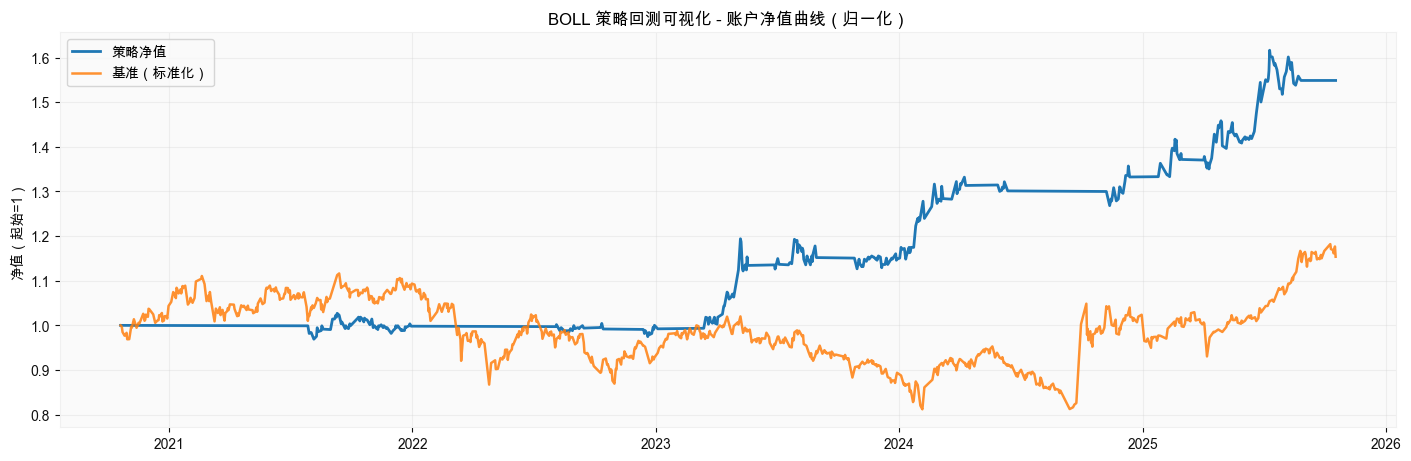

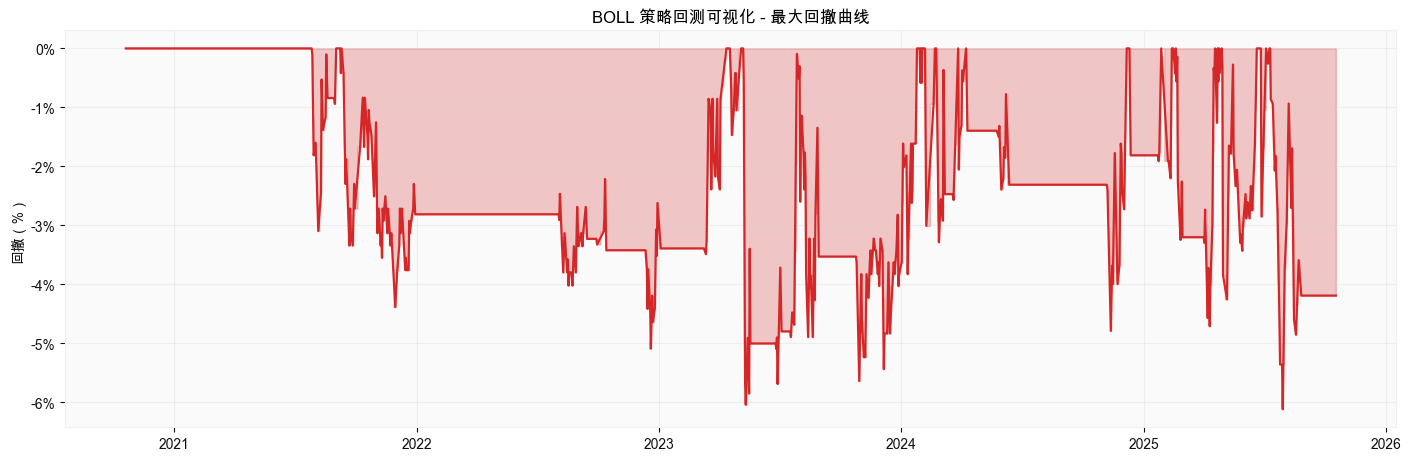

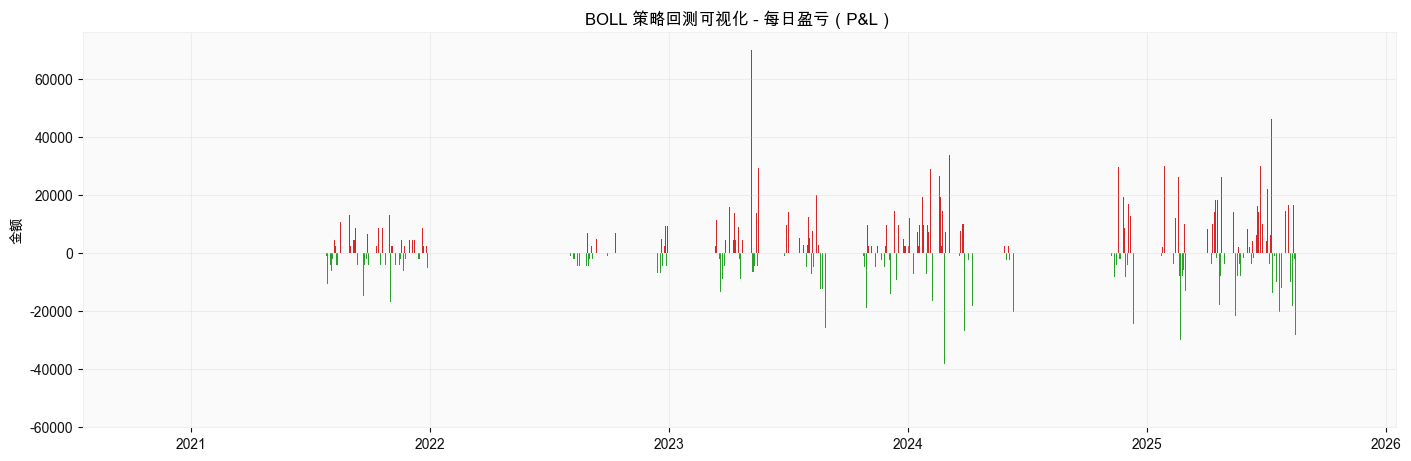

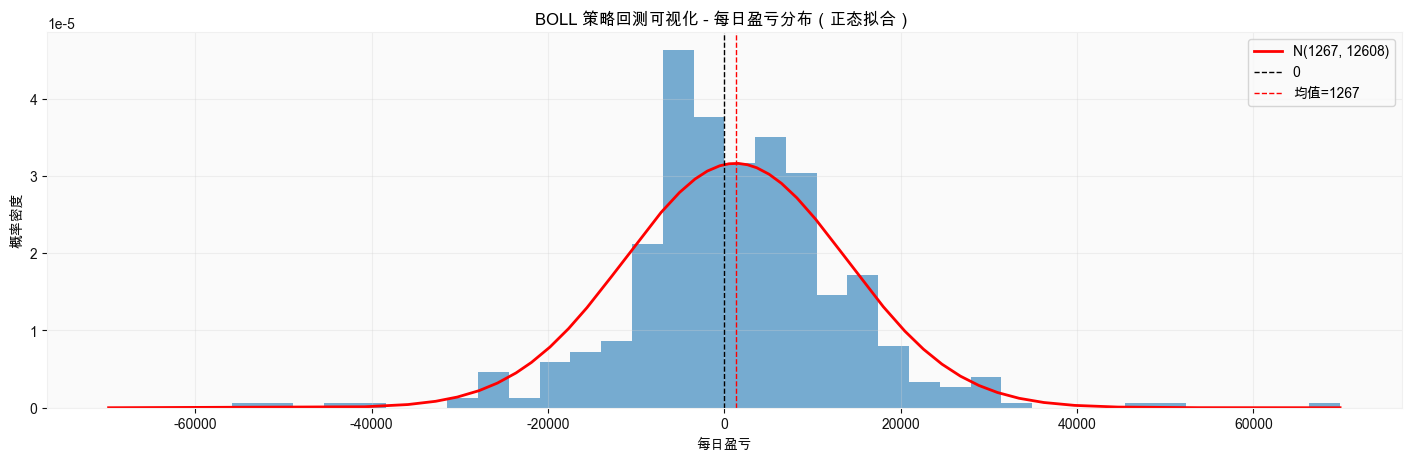

In [20]:
values_df = pd.DataFrame(trading_state['values'])
# 若想叠加基准，传入基准收盘价序列，如：benchmark_data['Close']
plot_backtest_dashboard(values_df, benchmark_series=benchmark_data['Close'], title_prefix="BOLL 策略回测可视化")
plt.show()